In [7]:
import pandas as pd
df=pd.read_csv("bestsellers with categories.csv")
df

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction
...,...,...,...,...,...,...,...
545,Wrecking Ball (Diary of a Wimpy Kid Book 14),Jeff Kinney,4.9,9413,8,2019,Fiction
546,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2016,Non Fiction
547,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2017,Non Fiction
548,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2018,Non Fiction


Index(['Name', 'Author', 'User Rating', 'Reviews', 'Price', 'Year', 'Genre'], dtype='object')


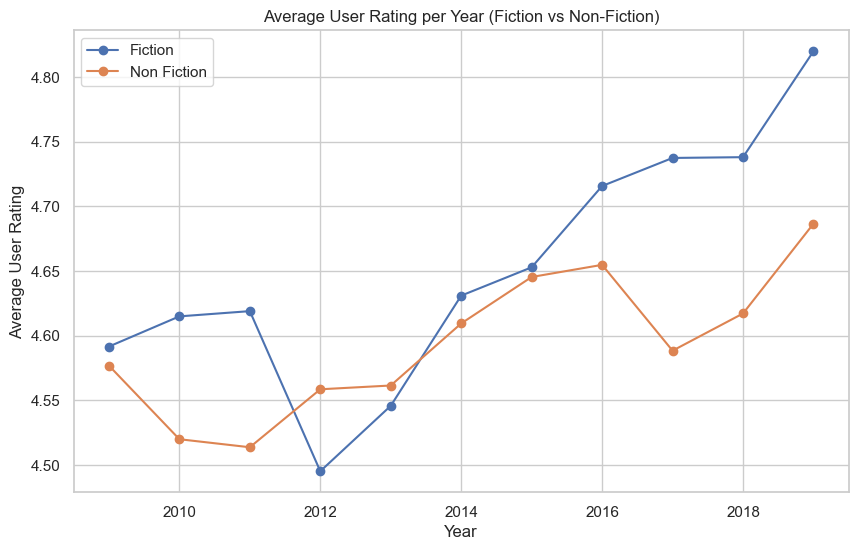

In [8]:
**#Q1. Plot a line chart showing the average user rating per year for Fiction and Non-Fiction books separately. Identify whether
#one genre consistently outrates the other.**
import matplotlib.pyplot as plt
print(df.columns)
avg_ratings = df.groupby(['Year', 'Genre'])['User Rating'].mean().unstack()
plt.figure(figsize=(10,6))
for genre in avg_ratings.columns:
    plt.plot(avg_ratings.index, avg_ratings[genre], marker='o', label=genre)
plt.title("Average User Rating per Year (Fiction vs Non-Fiction)")
plt.xlabel("Year")
plt.ylabel("Average User Rating")
plt.legend()
plt.grid(True)
plt.show()

**Observations and Insights**:
The chart shows year-wise average user ratings for Fiction and Non-Fiction books.
Both genres maintain consistently high ratings, generally between 4.5 and 4.8.
The two lines stay very close to each other across most years, indicating similar reader satisfaction.
In some years, Fiction slightly outrates Non-Fiction, while in others the opposite happens.
The lines intersect multiple times, showing that the leading genre changes over time

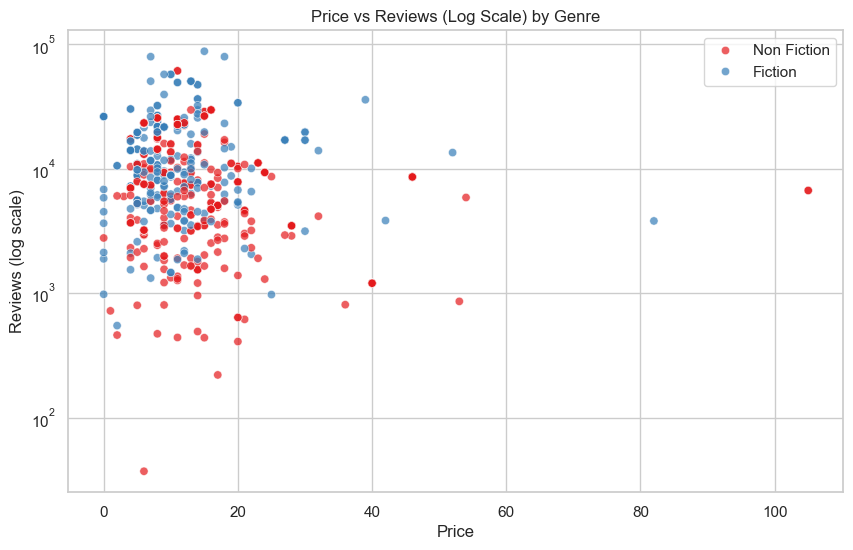

High-value, high-engagement outliers:
                                                  Name    Genre  Price  \
338                                      The Alchemist  Fiction     39   
382                              The Girl on the Train  Fiction     18   
392  The Goldfinch: A Novel (Pulitzer Prize for Fic...  Fiction     20   
393  The Goldfinch: A Novel (Pulitzer Prize for Fic...  Fiction     20   

     Reviews  
338    35799  
382    79446  
392    33844  
393    33844  


In [59]:
**#Q2. Create a scatter plot of &#39;Price&#39; vs. &#39;Reviews&#39; for all books. Color points by Genre. Use log scale for Reviews. Identify high- value, high-engagement outliers.**
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set(style="whitegrid")
plt.figure(figsize=(10,6))
sns.scatterplot( data=df, x="Price", y="Reviews", hue="Genre", palette="Set1", alpha=0.7
)
plt.yscale("log")
plt.title("Price vs Reviews (Log Scale) by Genre")
plt.xlabel("Price")
plt.ylabel("Reviews (log scale)")
plt.legend()
plt.show()
high_value = df[(df['Reviews'] > df['Reviews'].quantile(0.95)) & 
                (df['Price'] > df['Price'].quantile(0.75))]
print("High-value, high-engagement outliers:")
print(high_value[['Name', 'Genre', 'Price', 'Reviews']])

  **Observations & Insights:**
-> The scatter plot shows the relationship between book price and number of reviews, with color indicating genre.
-> A log scale on Reviews helps visualize both low- and high-review books clearly, since review counts vary widely.

Outliers (High-value, high-engagement):
->Books with very high review counts (top ~5%) and relatively high prices stand out as outliers.
->These represent strong-performing titles that achieve both:
->High commercial value (price)
->High user engagement (reviews)

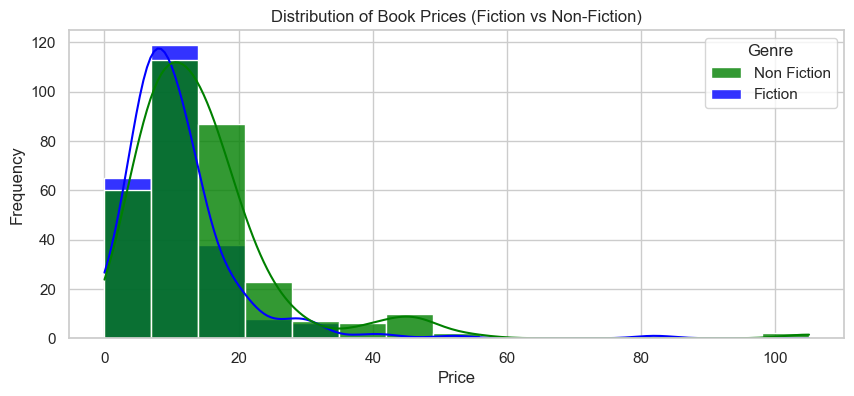

In [55]:
**#Q3. Visualize the distribution of book prices using a histogram. Overlay KDE curves for Fiction and Non-Fiction. Identify the
#most common price point for each genre.**
sns.set(style="whitegrid")
plt.figure(figsize=(10,4))
sns.histplot(
    data=df, x="Price", hue="Genre",kde=True,bins=15,palette={"Fiction": "blue", "Non Fiction": "green"}, alpha=0.8
)
plt.title("Distribution of Book Prices (Fiction vs Non-Fiction)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

**Observations & Insights**
->The histogram shows how book prices are distributed, with separate KDE curves for Fiction and Non-Fiction.
->The KDE (Kernel Density Estimate) curves help smooth the distribution and highlight the most common price ranges.

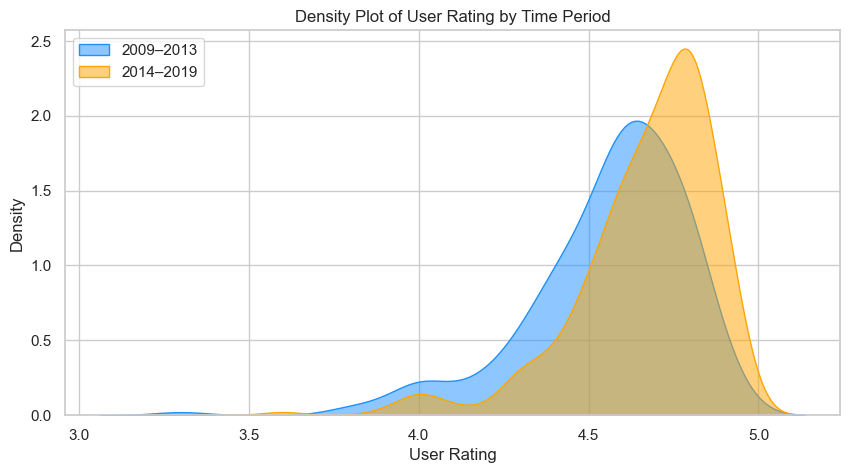

In [60]:
**#Q4. Create a density plot of &#39;User Rating&#39; grouped by year grouped into periods: 2009–2013, 2014–2019). Identify whether
#average quality shifted across periods.**
import matplotlib.pyplot as plt
import seaborn as sns
df["Period"] = df["Year"].apply(
    lambda x: "2009–2013" if x <= 2013 else "2014–2019"
)
sns.set(style="whitegrid")
plt.figure(figsize=(10,5))
sns.kdeplot(
    data=df[df["Period"] == "2009–2013"], x="User Rating", fill=True, color="dodgerblue",label="2009–2013",alpha=0.5
)
sns.kdeplot(
    data=df[df["Period"] == "2014–2019"], x="User Rating",fill=True, color="orange", label="2014–2019", alpha=0.5
)
plt.title("Density Plot of User Rating by Time Period")
plt.xlabel("User Rating")
plt.ylabel("Density")
plt.legend()
plt.show()

**Observations & Insights**
->The density plot compares user rating distributions across two time periods: 2009–2013 and 2014–2019.
->KDE curves show how ratings are concentrated and how they shift over time.
Conclusion:
There is a slight upward shift in average user ratings in 2014–2019, along with reduced variability. This suggests that book quality (or user perception of quality) improved marginally in the later period, but overall ratings remain consistently high across both periods.

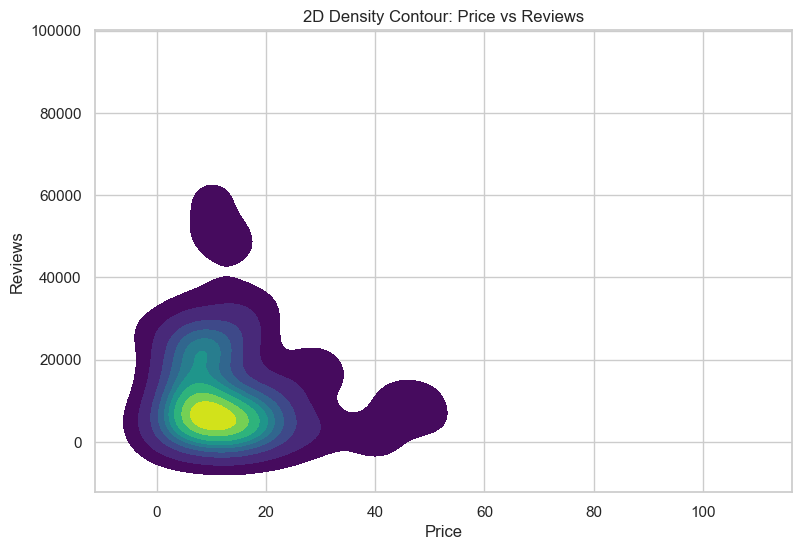

In [61]:
**#Q5. Use a 2D density contour plot (sns.kdeplot) of &#39;Price&#39; vs. &#39;Reviews&#39;. Identify clusters of popular affordable vs. expensive underperforming books.**

sns.set(style="whitegrid")
plt.figure(figsize=(9,6))
sns.kdeplot(
    data=df,x="Price",y="Reviews",fill=True,cmap="viridis",thresh=0.05,levels=10
)
plt.title("2D Density Contour: Price vs Reviews")
plt.xlabel("Price")
plt.ylabel("Reviews")
plt.show()

**Observations & Insights:**
->The 2D KDE contour plot shows where books are most densely concentrated based on Price and Reviews.
->Darker or more intense regions indicate clusters of similar book behavior.
Conclusion:
Most books cluster in the low-price region, with engagement varying widely. The strongest and most consistent pattern is that affordable books dominate high engagement, while expensive books are generally underrepresented in high-review zones.

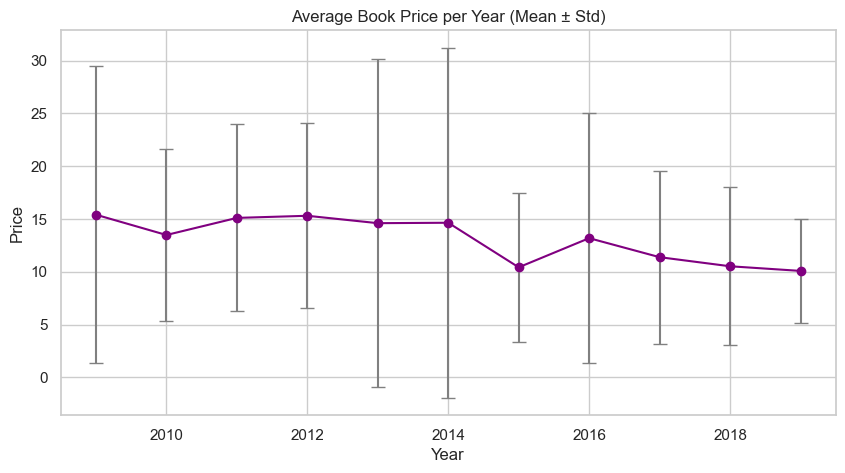

In [62]:
**#Q6. Visualize error bars of average price per year (mean ± std).Determine whether pricing became more or less variable over the decade.**
price_stats = df.groupby("Year")["Price"].agg(["mean", "std"])
plt.figure(figsize=(10,5))
plt.errorbar(
    price_stats.index, price_stats["mean"], yerr=price_stats["std"], fmt='o-', capsize=5, color="purple",ecolor="gray"
)
plt.title("Average Book Price per Year (Mean ± Std)")
plt.xlabel("Year")
plt.ylabel("Price")
plt.grid(True)
plt.show()

**Observations & Insights**
->The plot shows the average book price per year, with error bars representing standard deviation (± variability).
->Mean values indicate the overall pricing trend, while error bars show how spread out prices are in each year.

**Key observations:**
->The average price remains relatively stable across years, with only minor fluctuations.
->Some years show larger error bars, indicating more variation in book pricing.
->Other years have smaller error bars, suggesting more uniform pricing strategies.
->There is no strong upward or downward trend in mean price, meaning books did not consistently become more expensive or cheaper over time.

C:\Users\visla\AppData\Local\Temp\ipykernel_20524\1739023255.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


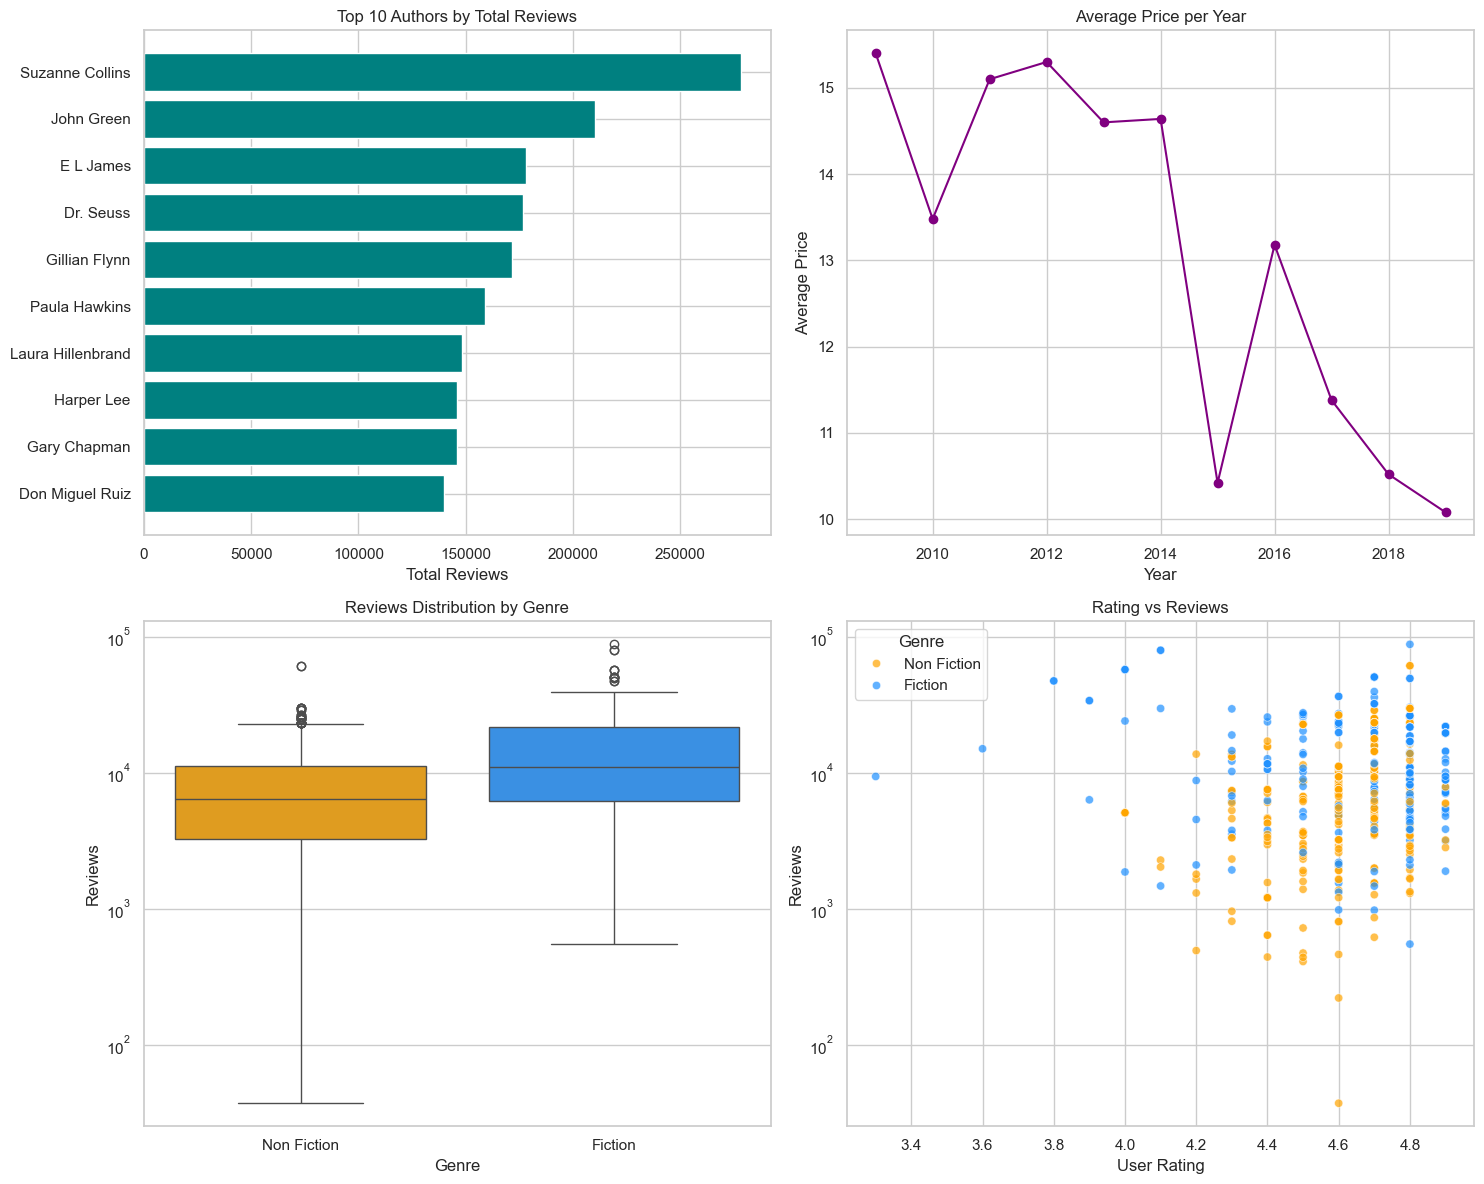

In [65]:
**#Q7. Build a 2x2 subplot grid: (a) bar chart of top 10 authors by total reviews, (b) line plot of average price per year, (c) boxplot
#of reviews by genre, (d) scatter of rating vs. reviews.**
sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
top_authors = df.groupby("Author")["Reviews"].sum().sort_values(ascending=False).head(10)
axes[0, 0].barh(top_authors.index, top_authors.values, color="teal")
axes[0, 0].set_title("Top 10 Authors by Total Reviews")
axes[0, 0].set_xlabel("Total Reviews")
axes[0, 0].invert_yaxis()
year_price = df.groupby("Year")["Price"].mean()

axes[0, 1].plot(year_price.index, year_price.values, marker="o", color="purple")
axes[0, 1].set_title("Average Price per Year")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Average Price")
axes[0, 1].grid(True)
sns.boxplot(
    data=df,
    x="Genre",
    y="Reviews",
    palette={"Fiction": "dodgerblue", "Non Fiction": "orange"},
    ax=axes[1, 0]
)
axes[1, 0].set_title("Reviews Distribution by Genre")
axes[1, 0].set_yscale("log")
sns.scatterplot(
    data=df, x="User Rating", y="Reviews",hue="Genre",palette={"Fiction": "dodgerblue", "Non Fiction": "orange"},ax=axes[1, 1],alpha=0.7
)
axes[1, 1].set_title("Rating vs Reviews")
axes[1, 1].set_yscale("log")

plt.tight_layout()
plt.show()

**Observations & Insights**
(a) Top Authors by Reviews
A small number of authors dominate total engagement.
Indicates high concentration of popularity among top writers.
(b) Average Price per Year
Price remains fairly stable over time.
No strong inflation or decline trend.
(c) Reviews by Genre (Boxplot)
Strong right-skew in reviews (few books get extremely high engagement).
Fiction shows slightly higher extreme values.
Log scale reveals clearer distribution.
(d) Rating vs Reviews
Weak relationship between rating and reviews.
High reviews do not always mean higher ratings.
Both genres behave similarly in rating distribution.

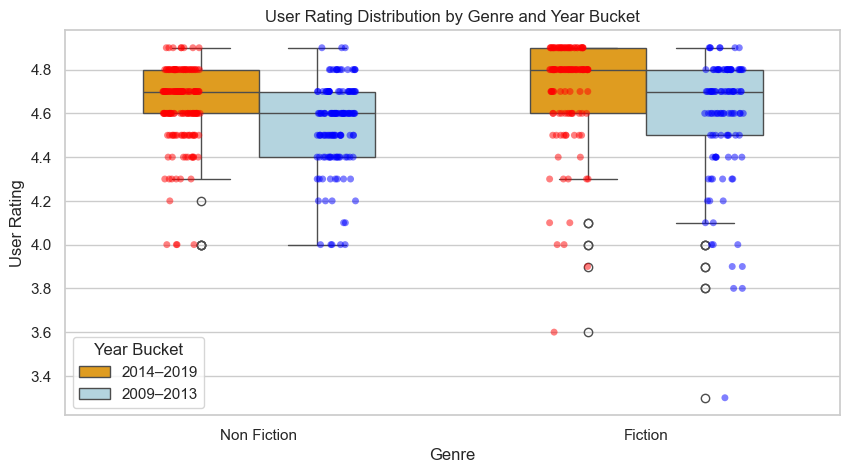

In [66]:
**#Q8. Use Seaborn&#39;s stripplot and boxplot (combined) to show user rating distribution by genre and year bucket. Identify
#outliers and rating trends.**
df["Year Bucket"] = df["Year"].apply( lambda x: "2009–2013" if x <= 2013 else "2014–2019"
)
sns.set(style="whitegrid")
plt.figure(figsize=(10,5))
sns.boxplot(
    data=df, x="Genre", y="User Rating", hue="Year Bucket", palette={"2009–2013": "lightblue", "2014–2019": "orange"}, width=0.6
)

sns.stripplot(
    data=df, x="Genre",y="User Rating",hue="Year Bucket",palette={"2009–2013": "blue", "2014–2019": "red"},dodge=True,alpha=0.5,size=5
)
plt.title("User Rating Distribution by Genre and Year Bucket")
plt.ylabel("User Rating")
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], title="Year Bucket")
plt.show()

**Observations & Insights**
->The boxplot shows the overall distribution of user ratings, while the stripplot shows individual book ratings.
->Combining both helps identify distribution shape + exact data points (outliers).
**Key observations:**
a)Ratings are highly concentrated
  Most books fall between 4.5 and 4.8
b)Very low variation in ratings overall
  Genre comparison
   Fiction and Non-Fiction show very similar rating distributions
   No strong difference in quality perception between genres
  Year bucket comparison
   2014–2019 shows a slightly tighter distribution
   Earlier years (2009–2013) show more spread and a few lower values
c) Outliers
A few books fall below the main cluster (~4.0–4.3)
These are visible as isolated points in stripplot
They represent lower-rated exceptions in an otherwise high-rating dataset

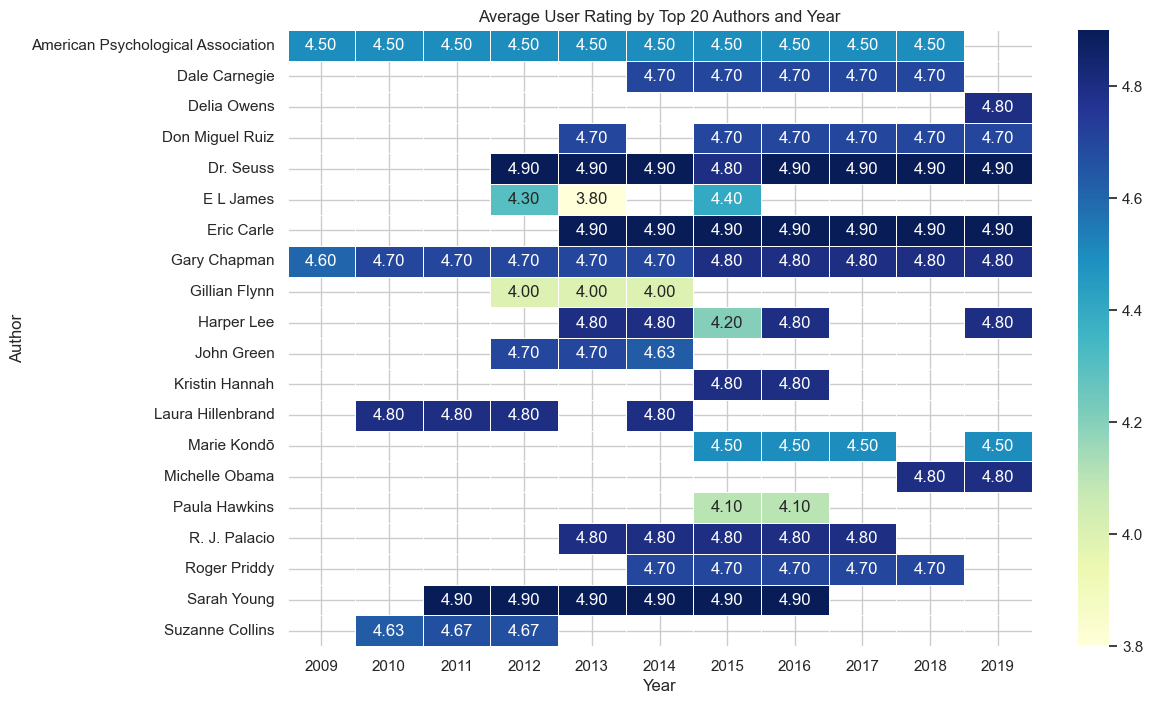

In [68]:
**#Q9. Create a Seaborn heatmap of average user rating by Author(top 20) and Year. Annotate and identify
#the most consistentlytop-rated authors.**

top_authors = df.groupby("Author")["Reviews"].sum().nlargest(20).index
df_top = df[df["Author"].isin(top_authors)]
heat_data = df_top.pivot_table( index="Author", columns="Year", values="User Rating", aggfunc="mean"
)
plt.figure(figsize=(12,8))
sns.heatmap(  heat_data, annot=True, cmap="YlGnBu", linewidths=0.5, fmt=".2f"
)
plt.title("Average User Rating by Top 20 Authors and Year")
plt.xlabel("Year")
plt.ylabel("Author")

plt.show()

**Observations & Insights:**
->The heatmap shows average user ratings across years for top 20 authors.
->Most values are concentrated in the 4.5–4.9 range, indicating consistently high-quality books.
Key insights:
 ->Several authors maintain stable high ratings across all years, showing strong consistency.
 ->A few authors stand out with near-uniform dark/high values, meaning they are consistently top-rated.

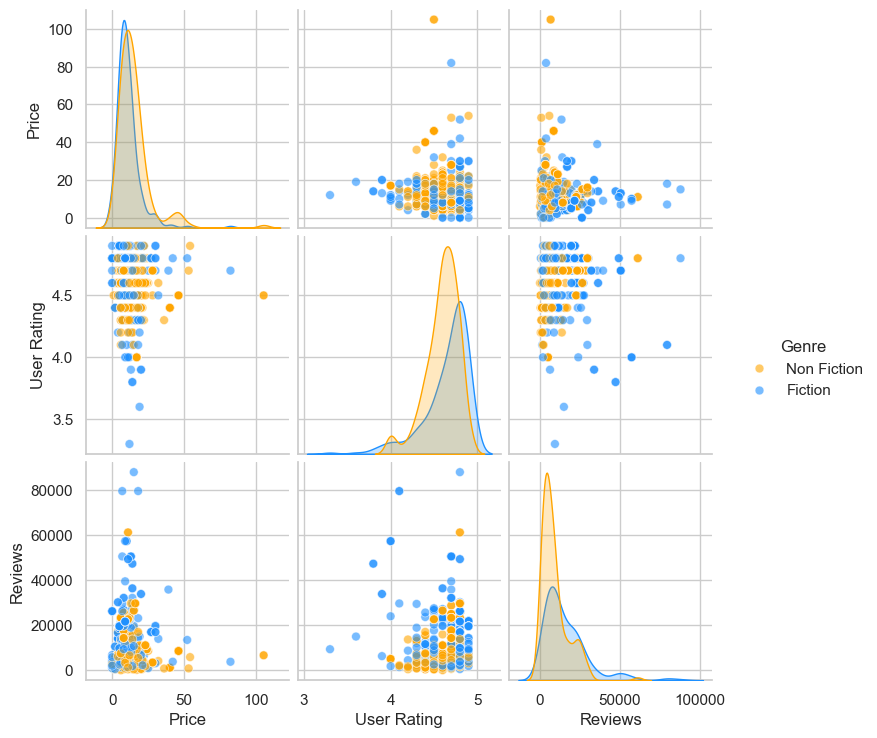

In [51]:
**#Q10. Use Seaborn&#39;s pairplot on &#39;Price&#39;, &#39;User Rating&#39;, and &#39;Reviews&#39; 
#grouped by Genre. Identify the relationships that best**
sns.set(style="whitegrid")
sns.pairplot(
    df,
    vars=["Price", "User Rating", "Reviews"],
    hue="Genre",
    palette={"Fiction": "dodgerblue", "Non Fiction": "orange"},
    diag_kind="kde",
    plot_kws={"alpha": 0.6,"s":40}
)

plt.show()


**Observations & Insights:**
Key relationships:
 a) Price vs Reviews
Weak/no correlation
High reviews occur at both low and medium prices
 b) User Rating vs Reviews
Very weak relationship
High reviews do NOT guarantee higher ratings
 c) Price vs User Rating
Almost no correlation
Expensive books are not necessarily better rated
Genre insights:
  Fiction:
More dense cluster of high reviews
Slightly more variability in engagement
  Non-Fiction:
More spread across price range
Similar rating distribution to Fiction